In [58]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind as sm_ttest
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize


# Activity 1

In [59]:
peng = pd.read_csv("penguins.csv")
print(peng.shape)
peng.head()

(344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Question 1

,count,mean,median,std
island,,,,
Biscoe,167,4716.02,4775.0,782.86
Dream,124,3712.90,3687.5,416.64
Torgersen,51,3706.37,3700.0,445.11


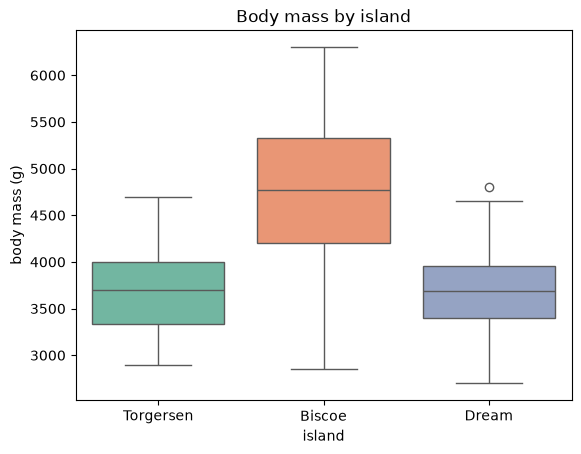

In [60]:
display(peng.groupby("island")["body_mass_g"].agg(["count", "mean", "median", "std"]).round(2))

sns.boxplot(data=peng.dropna(subset=["body_mass_g"]),
            x="island", y="body_mass_g",
            hue="island", palette="Set2", legend=False)
plt.xlabel("island")
plt.ylabel("body mass (g)")
plt.title("Body mass by island")
plt.show()

The boxplot shows that penguins on Biscoe island tend to be heavier than penguins on the other two islands. Most Biscoe penguins weigh around 4700 grams, while the typical Dream and Torgersen penguin weighs closer to 3700 grams. Dream and Torgersen look similar to each other, and my chart also shows that Biscoe has a wider spread of body masses.

## Question 2

In [61]:
peng = peng.dropna(subset=["body_mass_g"])
peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median()

b = peng.loc[peng["island"] == "Biscoe", "is_large"]
o = peng.loc[peng["island"] != "Biscoe", "is_large"] 

z, p = proportions_ztest([b.sum(), o.sum()], [len(b), len(o)], alternative="larger")
print(f"Biscoe large: {b.mean():.3f}   (n={len(b)})")
print(f"Other large:  {o.mean():.3f}   (n={len(o)})")
print(f"z = {z:.2f}   p = {p:.4f}")

Biscoe large: 0.784   (n=167)
Other large:  0.200   (n=175)
z = 10.81   p = 0.0000


The z-test for proportions rejects the null hypothesis (z = 10.81, p less than 0.001). About 78.4 percent of Biscoe penguins are large versus 20.0 percent on the other islands, so by the definition in the lab, Biscoe penguins are larger.

## Question 3

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,123
Dream,56,68,0
Torgersen,51,0,0


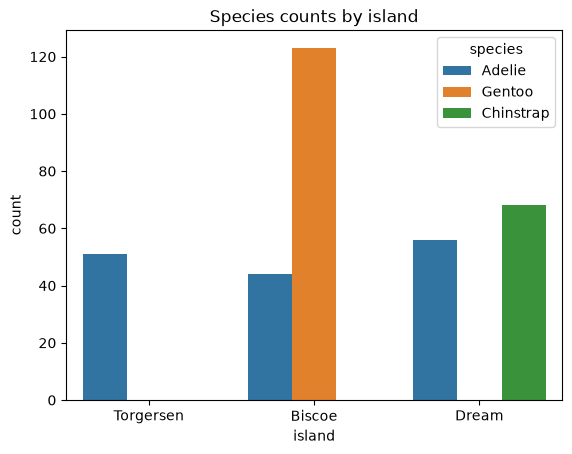

In [62]:
display(pd.crosstab(peng["island"], peng["species"]))

sns.countplot(data=peng, x="island", hue="species")
plt.title("Species counts by island")
plt.show()

,count,mean,median,std
species,,,,
Adelie,151,3700.66,3700.0,458.57
Chinstrap,68,3733.09,3700.0,384.34
Gentoo,123,5076.02,5000.0,504.12


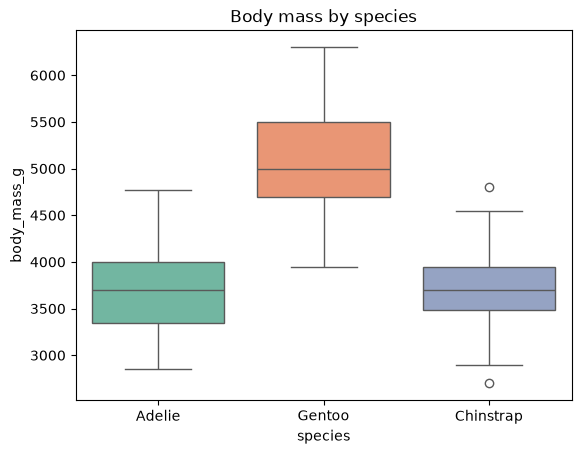

In [63]:
display(peng.groupby("species")["body_mass_g"].agg(["count", "mean", "median", "std"]).round(2))

sns.boxplot(data=peng.dropna(subset=["body_mass_g"]),
            x="species", y="body_mass_g",
            hue="species", palette="Set2", legend=False)
plt.title("Body mass by species")
plt.show()

Body mass by species shows the same pattern as body mass by island: Gentoo penguins weigh much more (median 5000 grams) than Adelie and Chinstrap penguins (median 3700 grams for both). The species bar chart shows that Gentoo penguins only live on Biscoe island, so the higher body mass we found on Biscoe is really a species effect, not an island effect. The species and island are confounded, so we cannot separate the two with this data.

## Question 4

In [64]:
adelie = peng[peng["species"] == "Adelie"].dropna(subset=["body_mass_g"])

display(adelie.groupby("island")["body_mass_g"].agg(["count", "mean", "median"]).round(2))

b_a = adelie.loc[adelie["island"] == "Biscoe", "is_large"]
o_a = adelie.loc[adelie["island"] != "Biscoe", "is_large"]

z, p = proportions_ztest([b_a.sum(), o_a.sum()], [len(b_a), len(o_a)], alternative="larger")
print(f"Biscoe Adelie large:  {b_a.mean():.3f}  (n={len(b_a)})")
print(f"Other Adelie large:   {o_a.mean():.3f}  (n={len(o_a)})")
print(f"z = {z:.2f}  p = {p:.4f}")

,count,mean,median
island,,,
Biscoe,44,3709.66,3750.0
Dream,56,3688.39,3575.0
Torgersen,51,3706.37,3700.0


Biscoe Adelie large:  0.205  (n=44)
Other Adelie large:   0.224  (n=107)
z = -0.27  p = 0.6052


Adelie is the only species that lives on more than one island, so I repeated the proportion test within Adelie penguins only. Within Adelie, Biscoe and the other islands have nearly the same fraction of large penguins (20.5 percent vs 22.4 percent), and the test is not significant (z = -0.27, p = 0.61). This shows the original result was driven by species composition. Biscoe looked larger because it is mostly the larger Gentoo species, not because the island itself makes penguins larger.

# Activity 2

In [65]:
df = pd.read_csv("DS6021-Fall26-Anonymized.csv")
print(df.shape)
df.head()

(86, 12)


,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,8/25/2026 8:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,8/25/2026 9:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,8/25/2026 13:43:23,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,8/25/2026 15:11:38,Data Science (concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,8/25/2026 15:26:11,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall


## Question 1

In [66]:
df_sleep = df[[
    "How many years ago did you receive your undergraduate degree?",
    "How many hours do you sleep in a typical night?"
]].rename(columns={
    "How many years ago did you receive your undergraduate degree?": "years_since_undergrad",
    "How many hours do you sleep in a typical night?": "sleep_hrs"
})

year_order = ["< 1 year", "1-3 years", "4-6 years", "7-10 years", "10+ years"]
df_sleep["years_since_undergrad"] = pd.Categorical(
    df_sleep["years_since_undergrad"], categories=year_order, ordered=True
)

bounds = df_sleep["sleep_hrs"].str.extractall(r"(\d+\.?\d*)")[0].astype(float)
df_sleep["sleep_hrs"] = bounds.groupby(level=0).agg(lambda x: x.head(2).mean())

print(df_sleep.head())
print(df_sleep.isna().sum())
(df_sleep["sleep_hrs"].unique()).T

  years_since_undergrad  sleep_hrs
0             4-6 years        8.0
1             1-3 years        8.0
2              < 1 year        8.0
3              < 1 year        8.0
4             1-3 years        8.0
years_since_undergrad    0
sleep_hrs                0
dtype: int64


array([8.  , 7.  , 6.5 , 9.  , 5.  , 8.5 , 4.5 , 7.5 , 6.  , 5.5 , 8.75,
       4.  , 8.25])

,count,mean,median,std
years_3,,,,
< 1 year,50,7.07,7.0,0.98
1-3 years,17,7.41,7.0,0.85
4+ years,19,7.42,8.0,1.17


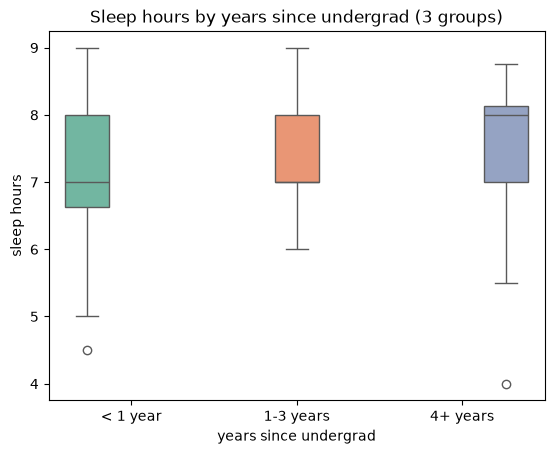

In [67]:
year_map = {
    "< 1 year": "< 1 year",
    "1-3 years": "1-3 years",
    "4-6 years": "4+ years",
    "7-10 years": "4+ years",
    "10+ years": "4+ years",
}
df_sleep["years_3"] = df_sleep["years_since_undergrad"].map(year_map)
df_sleep["years_3"] = pd.Categorical(
    df_sleep["years_3"],
    categories=["< 1 year", "1-3 years", "4+ years"],
    ordered=True
)

display(df_sleep.groupby("years_3")["sleep_hrs"].agg(["count", "mean", "median", "std"]).round(2))

sns.boxplot(data=df_sleep, x="years_3", y="sleep_hrs",
            hue="years_3", palette="Set2")
plt.xlabel("years since undergrad")
plt.ylabel("sleep hours")
plt.title("Sleep hours by years since undergrad (3 groups)")
plt.show()

The three groups have similar sleep hours. The averages are 7.07 hours for less than 1 year, 7.41 hours for 1 to 3 years, and 7.42 hours for 4 or more years, with medians of 7, 7, and 8. The boxplot shows the groups overlap heavily, so visually there is no clear difference in sleep across the three groups.

## Question 2

In [68]:
groups = [df_sleep.loc[df_sleep["years_3"] == s, "sleep_hrs"]
          for s in ["< 1 year", "1-3 years", "4+ years"]]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

model = ols("sleep_hrs ~ C(years_3)", data=df_sleep).fit()
print(sm.stats.anova_lm(model, typ=2))

Levene's test p-value: 0.75
               sum_sq    df         F    PR(>F)
C(years_3)   2.516123   2.0  1.252339  0.291179
Residual    83.379226  83.0       NaN       NaN


The Levene test for equal variance gives a p-value of 0.75, so the assumption of equal variance holds. The ANOVA gives an F statistic of 1.25 with a p-value of 0.29, so there is no significant difference in mean sleep hours among the three groups. One thing to note is that ANOVA treats the groups as unordered categories, but years since undergrad is an ordered variable, so the analysis ignores the ordering in the data.

## Question 3

The original buckets are somewhat arbitrary and, based on my findings in the previous lab, are heavily weighted to less than 1 year, leaving the other buckets with a pretty limited sample size. Merging into three groups does not fix this. The results were very similar, because combining the last three groups into one did not address the underlying issue with the data's distribution. For a redesign, I would get more granular at the lower values, like capturing the number of months under 1 year, and also allow distinct values for years and months that could be grouped later. So my recommendation would be a number of months dropdown from 0 to 11, and a number of years dropdown from 0 to 10 or more.

## Question 4

I think this is a very good real world example for data cleaning, since it shows how relatively simple questions can create very messy data, like hours of sleep having strings with multiple numbers and favorite sports having different strings representing the same thing. The main flaw for practicing comparisons is the limited size of the dataset, which also causes issues with inference, since a larger dataset would provide clearer results.

# Activity 3

In [69]:
trial = pd.read_csv("Clinical_trial.csv")
print(trial.shape)
trial.head()

(27, 2)


,Drug,Pain_Rating
0,A,4
1,A,5
2,A,4
3,A,3
4,A,2


In [70]:
print(trial.columns.tolist())
print(trial["Drug"].value_counts(dropna=False))
trial["Pain_Rating"].describe()

['Drug', 'Pain_Rating']
Drug
A    9
B    9
C    9
Name: count, dtype: int64


count    27.000000
mean      5.111111
std       1.476309
min       2.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       8.000000
Name: Pain_Rating, dtype: float64

## Question 1

,count,mean,median,std
Drug,,,,
A,9,3.67,4.0,0.87
B,9,5.78,6.0,1.48
C,9,5.89,6.0,0.78


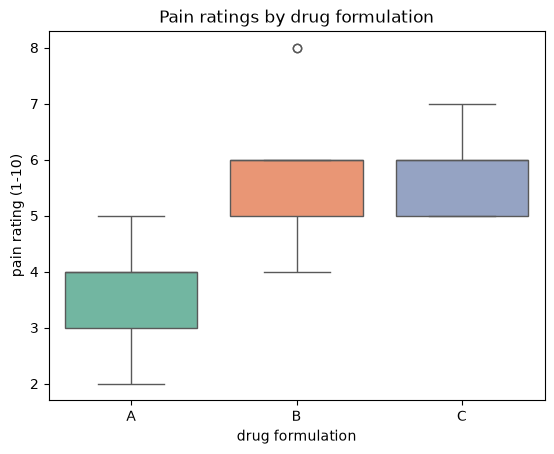

In [71]:
display(trial.groupby("Drug")["Pain_Rating"].agg(["count", "mean", "median", "std"]).round(2))

sns.boxplot(data=trial, x="Drug", y="Pain_Rating",
            hue="Drug", palette="Set2", legend=False)
plt.xlabel("drug formulation")
plt.ylabel("pain rating (1-10)")
plt.title("Pain ratings by drug formulation")
plt.show()

The boxplot shows that drug A has noticeably lower pain ratings than drugs B and C. The average pain rating for A is 3.67, while B averages 5.78 and C averages 5.89, with both B and C having a median of 6. The spread for B and C overlaps heavily, while A is both lower and tighter. This suggests drug A is the most effective at reducing migraine pain, at least descriptively.

## Question 2

In [72]:
groups = [trial.loc[trial["Drug"] == d, "Pain_Rating"] for d in ["A", "B", "C"]]
print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

model = ols("Pain_Rating ~ C(Drug)", data=trial).fit()
print(sm.stats.anova_lm(model, typ=2))

tukey = pairwise_tukeyhsd(trial["Pain_Rating"], trial["Drug"], alpha=0.05)
print(tukey)

Levene's test p-value: 0.21
             sum_sq    df         F    PR(>F)
C(Drug)   28.222222   2.0  11.90625  0.000256
Residual  28.444444  24.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   2.1111 0.0011  0.8295 3.3927   True
     A      C   2.2222 0.0006  0.9406 3.5038   True
     B      C   0.1111 0.9745 -1.1705 1.3927  False
---------------------------------------------------


We tested whether the three drug formulations differ in their effect on migraine pain. An analysis of variance showed a significant difference between the formulations (p less than 0.001), and a follow-up comparison showed that formulation A reduces pain the most, with an average rating of 3.67 compared to 5.78 for B and 5.89 for C. Formulations B and C are not statistically different from each other. So drug A is the most effective formulation.

## Question 3

The prediction goal of a supervised model would be to predict a patient's pain rating based on the drug formulation, and eventually to predict which formulation would be most effective for a specific patient based on their symptoms and medical history. Inference is used to determine which drugs are most effective in general and which are worth investing in, while prediction is used to decide which drug would be most effective for a specific patient.

# Activity 4

## Question 1

In [73]:
analysis = TTestIndPower()
n_per_arm = 4 * 300  # 1200

d = analysis.solve_power(effect_size=None, nobs1=n_per_arm,
                         alpha=0.05, power=0.80, ratio=1.0,
                         alternative="two-sided")
print(f"Minimum detectable Cohen's d = {d:.3f}")
print(f"In minutes = {d * 4:.2f}")   # SD is 4 minutes
print(f"As % of A = {d * 4 / 12:.1%}")  # A averages 12 minutes


Minimum detectable Cohen's d = 0.114
In minutes = 0.46
As % of A = 3.8%


The minimum effect size we could measure after 4 days is a Cohen's d of 0.114, which translates to about 0.46 minutes, or a 3.8 percent increase over version A's current average of 12 minutes. This was computed with an alpha of 0.05, a target power of 0.8, and 300 users per group per day, which gives 1200 users per group after 4 days.

## Question 2

The minimum detectable effect after 4 days is about 0.46 minutes, or a 3.8 percent increase over the current 12 minute average. The observed difference between version B and version A is 0.5 minutes, which is above that threshold, so the results clear the bar for what this test can detect. However, it is very close to the boundary, so I would treat the result as promising but not definitive. Running the test longer would give us more confidence.

## Question 3

In [74]:
mde_table = pd.DataFrame({"days": [4, 5, 7, 10, 14, 21, 28]})

mde_table["n_per_arm"] = mde_table["days"] * 300
mde_table["mde_minutes"] = mde_table["n_per_arm"].apply(
    lambda n: analysis.solve_power(effect_size=None, nobs1=n,
                                   alpha=0.05, power=0.80,
                                   ratio=1.0, alternative="two-sided") * 4
)
mde_table

,days,n_per_arm,mde_minutes
0,4,1200,0.457680
1,5,1500,0.409328
2,7,2100,0.345914
3,10,3000,0.289398
4,14,4200,0.244570
5,21,6300,0.199684
6,28,8400,0.172925


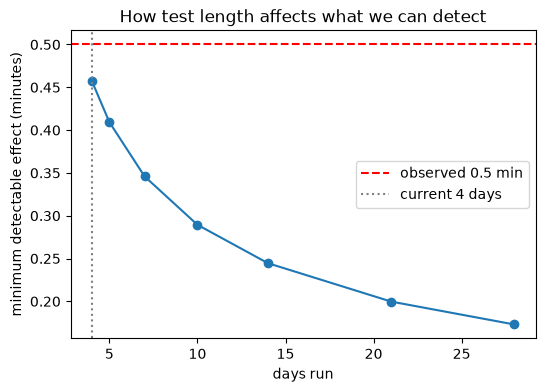

In [75]:
plt.figure(figsize=(6, 4))
plt.plot(mde_table["days"], mde_table["mde_minutes"], marker="o")
plt.axhline(0.5, color="red", linestyle="--", label="observed 0.5 min")
plt.axvline(4, color="gray", linestyle=":", label="current 4 days")
plt.xlabel("days run")
plt.ylabel("minimum detectable effect (minutes)")
plt.title("How test length affects what we can detect")
plt.legend()
plt.show()

1) After 4 days, this test can only detect differences of about 0.46 minutes or larger. The observed 0.5 minute difference between B and A clears that bar, but only barely.

2) Running the test longer shrinks the detectable effect. At 7 days we could detect a 0.35 minute difference, at 14 days 0.24 minutes, and at 28 days just 0.17 minutes.

3) The observed 0.5 minute improvement is promising but not conclusive at 4 days. Because the result sits at the boundary of what the test can detect, the safer decision is to keep the test running.

## Question 4

Since the observed difference clears the threshold we set before the test, the results meet the standard we agreed on for making a decision. I would frame it to leadership as a data supported rollout. Version B showed an improvement of about 0.5 minutes, which is above the minimum effect we could reliably detect after 4 days. The caveat is that it is close to the boundary, so I would recommend launching B with monitoring and a plan to check the real world numbers after launch, rather than treating the improvement as guaranteed.

# AI Acknowledgment

I used an AI assistant to help write code for this lab. I checked the outputs myself against the data and the class materials to make sure the code worked correctly. I also used AI to help with spelling and grammar in my written answers. All questions were answered in my own words.